In [2]:
import torch 
import torch.nn as nn
import torch.nn.functional as F 
device='cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device} device")
block_size=8
batch_size=4

Using cpu device


In [3]:
from google.colab import drive
drive.mount('/content/drive')


ModuleNotFoundError: No module named 'google.colab'

In [3]:
with open ('/content/drive/MyDrive/pg22566.txt', 'r', encoding="utf-8") as f:
    text = f.read()
print(len(text))

252022


In [4]:
from pathlib import Path
text = Path("pg22566.txt").read_text(encoding="utf-8")
print(len(text))

252022


In [5]:
print(text[:200])

The Project Gutenberg eBook of Dorothy and the Wizard in Oz
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no rest


In [6]:
chars=sorted(set(text))
print(chars)

['\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '—', '‘', '’', '“', '”', '•', '™', '\ufeff']


In [7]:
print(len(chars))

92


In [8]:
string_to_int = {ch:i for i, ch in enumerate(chars)}
int_to_string = {i:ch for i, ch in enumerate(chars)}
encode=lambda s: [string_to_int[c] for c in s]
decode=lambda l: ''.join([int_to_string[i] for i in l])
print(encode("hello world"))
print(decode(encode("hello world")))


[65, 62, 69, 69, 72, 1, 80, 72, 75, 69, 61]
hello world


In [9]:
data=torch.tensor(encode(text),dtype=torch.long)
print(data[:100])

tensor([91, 48, 65, 62,  1, 44, 75, 72, 67, 62, 60, 77,  1, 35, 78, 77, 62, 71,
        59, 62, 75, 64,  1, 62, 30, 72, 72, 68,  1, 72, 63,  1, 32, 72, 75, 72,
        77, 65, 82,  1, 58, 71, 61,  1, 77, 65, 62,  1, 51, 66, 83, 58, 75, 61,
         1, 66, 71,  1, 43, 83,  0,  1,  1,  1,  1,  0, 48, 65, 66, 76,  1, 62,
        59, 72, 72, 68,  1, 66, 76,  1, 63, 72, 75,  1, 77, 65, 62,  1, 78, 76,
        62,  1, 72, 63,  1, 58, 71, 82, 72, 71])


In [19]:
n=int(0.8*len(data))
train_data=data[:n]
val_data=data[n:]
def get_batch(split):
    data=train_data if split=='train' else val_data
    ix=torch.randint(len(data)-block_size,(batch_size,))
    x=torch.stack([data[i:i+block_size] for i in ix])
    y=torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device),y.to(device)
x,y=get_batch('train')
print('inputs:')
print(x.shape)
print(x)
print('targets:')
print(y.shape)
print(y)

inputs:
torch.Size([4, 8])
tensor([[77, 65, 62, 70,  1, 59, 58, 60],
        [70, 66, 69, 68, 14,  3,  0,  0],
        [62,  1, 59, 62, 64, 58, 71,  1],
        [ 1, 76, 72, 70, 62, 77, 65, 66]])
targets:
torch.Size([4, 8])
tensor([[65, 62, 70,  1, 59, 58, 60, 68],
        [66, 69, 68, 14,  3,  0,  0,  3],
        [ 1, 59, 62, 64, 58, 71,  1, 77],
        [76, 72, 70, 62, 77, 65, 66, 71]])


In [20]:
block_size=8
x=train_data[:block_size]
y=train_data[1:block_size+1]
for t in range(block_size):
    context=x[:t+1]
    target=y[:t+1]
    print(f"when input is {context} the target is {target}")

when input is tensor([91]) the target is tensor([48])
when input is tensor([91, 48]) the target is tensor([48, 65])
when input is tensor([91, 48, 65]) the target is tensor([48, 65, 62])
when input is tensor([91, 48, 65, 62]) the target is tensor([48, 65, 62,  1])
when input is tensor([91, 48, 65, 62,  1]) the target is tensor([48, 65, 62,  1, 44])
when input is tensor([91, 48, 65, 62,  1, 44]) the target is tensor([48, 65, 62,  1, 44, 75])
when input is tensor([91, 48, 65, 62,  1, 44, 75]) the target is tensor([48, 65, 62,  1, 44, 75, 72])
when input is tensor([91, 48, 65, 62,  1, 44, 75, 72]) the target is tensor([48, 65, 62,  1, 44, 75, 72, 67])


In [21]:
x=train_data[:block_size]
y=train_data[1:block_size+1]
for t in range(block_size):
    context=x[:t+1]
    target=y[:t+1]
    print(f"when input is {context} the target is {target}")

when input is tensor([91]) the target is tensor([48])
when input is tensor([91, 48]) the target is tensor([48, 65])
when input is tensor([91, 48, 65]) the target is tensor([48, 65, 62])
when input is tensor([91, 48, 65, 62]) the target is tensor([48, 65, 62,  1])
when input is tensor([91, 48, 65, 62,  1]) the target is tensor([48, 65, 62,  1, 44])
when input is tensor([91, 48, 65, 62,  1, 44]) the target is tensor([48, 65, 62,  1, 44, 75])
when input is tensor([91, 48, 65, 62,  1, 44, 75]) the target is tensor([48, 65, 62,  1, 44, 75, 72])
when input is tensor([91, 48, 65, 62,  1, 44, 75, 72]) the target is tensor([48, 65, 62,  1, 44, 75, 72, 67])


In [22]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table=nn.Embedding(vocab_size,vocab_size)
    def forward(self, idx, targets=None):
        logits=self.token_embedding_table(idx)
        if targets is None:
            loss=None
        else:
            B,T,C=logits.shape
            logits=logits.view(B*T,C)
            targets=targets.view(B*T)
            loss=F.cross_entropy(logits,targets)
        return logits,loss
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self.forward(idx)
            logits=logits[:,-1,:]
            probs=F.softmax(logits,dim=-1)
            idx_next=torch.multinomial(probs,num_samples=1)
            idx=torch.cat((idx,idx_next),dim=1)
        return idx
    
model=BigramLanguageModel(vocab_size=len(chars))
m=model.to(device)
context=torch.zeros((1,1),dtype=torch.long,device=device)
generated_chars=model.generate(context,max_new_tokens=500)[0].tolist()
print(generated_chars)

[0, 63, 91, 22, 1, 39, 76, 57, 26, 72, 2, 77, 31, 51, 77, 64, 3, 68, 21, 21, 56, 30, 61, 89, 52, 91, 55, 45, 72, 50, 66, 38, 83, 82, 2, 63, 41, 68, 16, 12, 58, 47, 66, 26, 5, 61, 28, 47, 41, 10, 1, 58, 76, 30, 2, 21, 5, 57, 57, 42, 41, 61, 30, 48, 1, 62, 65, 35, 86, 30, 29, 37, 20, 32, 6, 22, 56, 70, 58, 25, 89, 17, 73, 17, 60, 8, 80, 80, 8, 68, 66, 59, 35, 50, 70, 44, 2, 17, 18, 3, 53, 68, 36, 69, 33, 77, 63, 71, 88, 82, 91, 26, 24, 10, 77, 90, 76, 68, 63, 54, 19, 75, 39, 31, 74, 82, 73, 62, 6, 27, 37, 28, 54, 89, 24, 77, 26, 41, 4, 43, 37, 18, 5, 65, 62, 23, 3, 53, 46, 84, 71, 29, 51, 39, 67, 85, 30, 16, 15, 60, 31, 38, 77, 15, 53, 35, 69, 7, 41, 71, 43, 74, 51, 77, 85, 86, 73, 60, 5, 66, 71, 53, 16, 86, 20, 41, 66, 84, 83, 41, 85, 63, 10, 53, 2, 5, 5, 6, 71, 88, 61, 20, 4, 31, 18, 8, 5, 89, 42, 59, 84, 19, 25, 80, 60, 46, 74, 51, 87, 89, 1, 51, 60, 4, 90, 71, 68, 72, 11, 51, 47, 17, 72, 3, 15, 57, 79, 53, 59, 77, 75, 60, 72, 82, 81, 79, 14, 46, 91, 67, 85, 77, 31, 38, 22, 78, 56, 89

In [24]:
optim=torch.optim.AdamW(model.parameters(),lr=3e-4)
for i in range(40000):
    xb,yb=get_batch('train')
    logits,loss=model.forward(xb,yb)
    optim.zero_grad(set_to_none=True)
    loss.backward()
    optim.step()
    optim.zero_grad(set_to_none=True)
print(loss.item())

2.5006227493286133


In [25]:
@torch.no_grad()
def estimate_loss(eval_iters=200):
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

losses = estimate_loss()
print(f"train loss: {losses['train']:.4f}")
print(f"val loss: {losses['val']:.4f}")


train loss: 2.4030
val loss: 2.6627


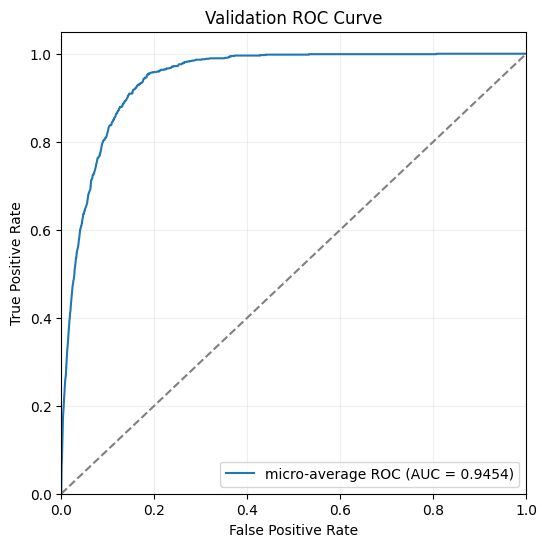

Validation micro-average ROC-AUC: 0.9454


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

@torch.no_grad()
def plot_val_roc_auc(eval_batches=30):
    model.eval()
    y_true_all = []
    y_score_all = []
    vocab_size = len(chars)

    for _ in range(eval_batches):
        X, Y = get_batch("val")
        logits, _ = model(X)
        probs = F.softmax(logits, dim=-1)

        y_true_all.append(Y.reshape(-1).cpu().numpy())
        y_score_all.append(probs.reshape(-1, vocab_size).cpu().numpy())

    model.train()

    y_true = np.concatenate(y_true_all)
    y_score = np.concatenate(y_score_all)

    y_true_bin = label_binarize(y_true, classes=np.arange(vocab_size))
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"micro-average ROC (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    plt.show()

    print(f"Validation micro-average ROC-AUC: {roc_auc:.4f}")

plot_val_roc_auc(eval_batches=30)


In [27]:
context=torch.zeros((1,1),dtype=torch.long,device=device)
generated_chars=model.generate(context,max_new_tokens=500)[0].tolist()
print(decode(generated_chars))


Rqult "

otasecls my," there wa tizd y

ily in beegm; Thelled os f s Wharyetuc."ar sooche, aneedrthe orud I th
poie frpe nghey Alld an naskem?" Jwrof nj8er mangey, Wind igenveno isptoraguto. stoblinif wenoty tfa ppororow,




herimad--ste po m, t o It QVtthouly. hehatto sigletant adit,
[Mon, hedeve _'land tsoy HAto Buloka s ISouio ag?"Wigoy ch pey l

"
"Wenghas'vosthenoug tren waressa lemabuny ikisid m Mshy ifl
"Gang, wang Withaten tled vea m th,"
BEp, s a I ay.


"
feas ptheatty aithere hin nut
